# MRIxFields2026 — Evaluation

Evaluate predicted volumes against ground-truth scans.

1. **Setup** — paths to predictions and targets
2. **Single pair** — load one pred-target pair, inspect shapes/intensity
3. **Voxel metrics** — nRMSE, SSIM, LPIPS
4. **Visualization** — source / pred / target / error map
5. **Batch evaluation** — aggregate across the validation set, dump CSV
6. **Segmentation metrics** *(optional)* — Dice and volume consistency on SynthSeg labels

Prerequisite: predictions from notebook 02 (saved in `tmp/inference/`) or from `Baseline/scripts/inference.py`.

In [1]:
import sys, os
from pathlib import Path

# Resolve paths relative to this notebook's location.
# nbconvert may run from repo root, so we check both possibilities.
if Path('tmp/inference').exists():
    _tutorial = Path('.')
elif Path('Tutorial/tmp/inference').exists():
    _tutorial = Path('Tutorial')
else:
    _tutorial = Path('.')

sys.path.insert(0, str(_tutorial / '..' / 'Baseline'))
sys.path.insert(0, str(_tutorial / '..' / 'Evaluation'))

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from mrixfields.env import load_env
from mrixfields.data.utils import load_nifti, list_nifti_files
from evaluate import (
    compute_nrmse, compute_ssim, compute_lpips,
    evaluate_pair, match_by_subject_prefix, find_seg_file,
)

load_env()
DATA_DIR = Path(os.environ['DATA_DIR'])
INFERENCE_DIR = (_tutorial / 'tmp' / 'inference').resolve()

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print(f'Predictions: {INFERENCE_DIR.relative_to(INFERENCE_DIR.parent.parent)}')
print(f'Data root:   .../{DATA_DIR.name}')

Predictions: tmp/inference
Data root:   .../full_data_20260414


## 1. Locate a prediction-target pair

Predictions are organised by source field (e.g. `0.1T/`); targets are the 7T scan of the same subject. Match by subject ID prefix (e.g. `0001`).

In [2]:
pred_files = sorted(INFERENCE_DIR.rglob('*_pred.nii.gz'))
target_dir = DATA_DIR / 'Training_prospective' / 'T1W' / '7T'

if not pred_files:
    print(f'No predictions found — run notebook 02 first.')
    print('Run notebook 02 first to generate predictions.')
else:
    print(f'Predictions: {len(pred_files)} files')
    print(f'Target dir:  .../{target_dir.relative_to(DATA_DIR)}')
    for p in pred_files:
        print(f'  {p.name}')

Predictions: 1 files
Target dir:  .../Training_prospective/T1W/7T
  P_T1W_7T_0007_pred.nii.gz


## 2. Voxel-level metrics on a single pair

- **nRMSE** — `||pred - target||₂ / ||target||₂` within a brain mask. Lower is better.
- **SSIM** — slice-wise structural similarity, averaged. Range [0, 1], higher is better.
- **LPIPS** — perceptual distance with an AlexNet backbone. Lower is better.

`evaluate_pair` handles normalisation (`pred` already in [0,1] from inference, `target` clipped at the 99.5th percentile) and brain masking.

In [3]:
# Pick subject 0007 (the demo prediction from notebook 02)
subject_id = '0007'
pred_path = next((p for p in pred_files if subject_id in p.name), None)
tgt_path  = target_dir / f'P_T1W_7T_{subject_id}.nii.gz'
assert pred_path and tgt_path.exists(), f'Subject {subject_id} not found in pred or target'
print(f'Pred:   {pred_path.name}')
print(f'Target: {tgt_path.name}')

result = evaluate_pair(pred_path, tgt_path, metrics=['nrmse', 'ssim', 'lpips'])
for k, v in result.items():
    print(f'  {k:>6s}: {v:.4f}')

Pred:   P_T1W_7T_0007_pred.nii.gz
Target: P_T1W_7T_0007.nii.gz


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


... UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
... UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: ...


   nrmse: 0.3848
    ssim: 0.7388
   lpips: 0.1431


## 3. Visualize prediction vs. ground truth

Three axial slices (mid-1/4, mid, mid+1/4) showing prediction, target, and the absolute error map.

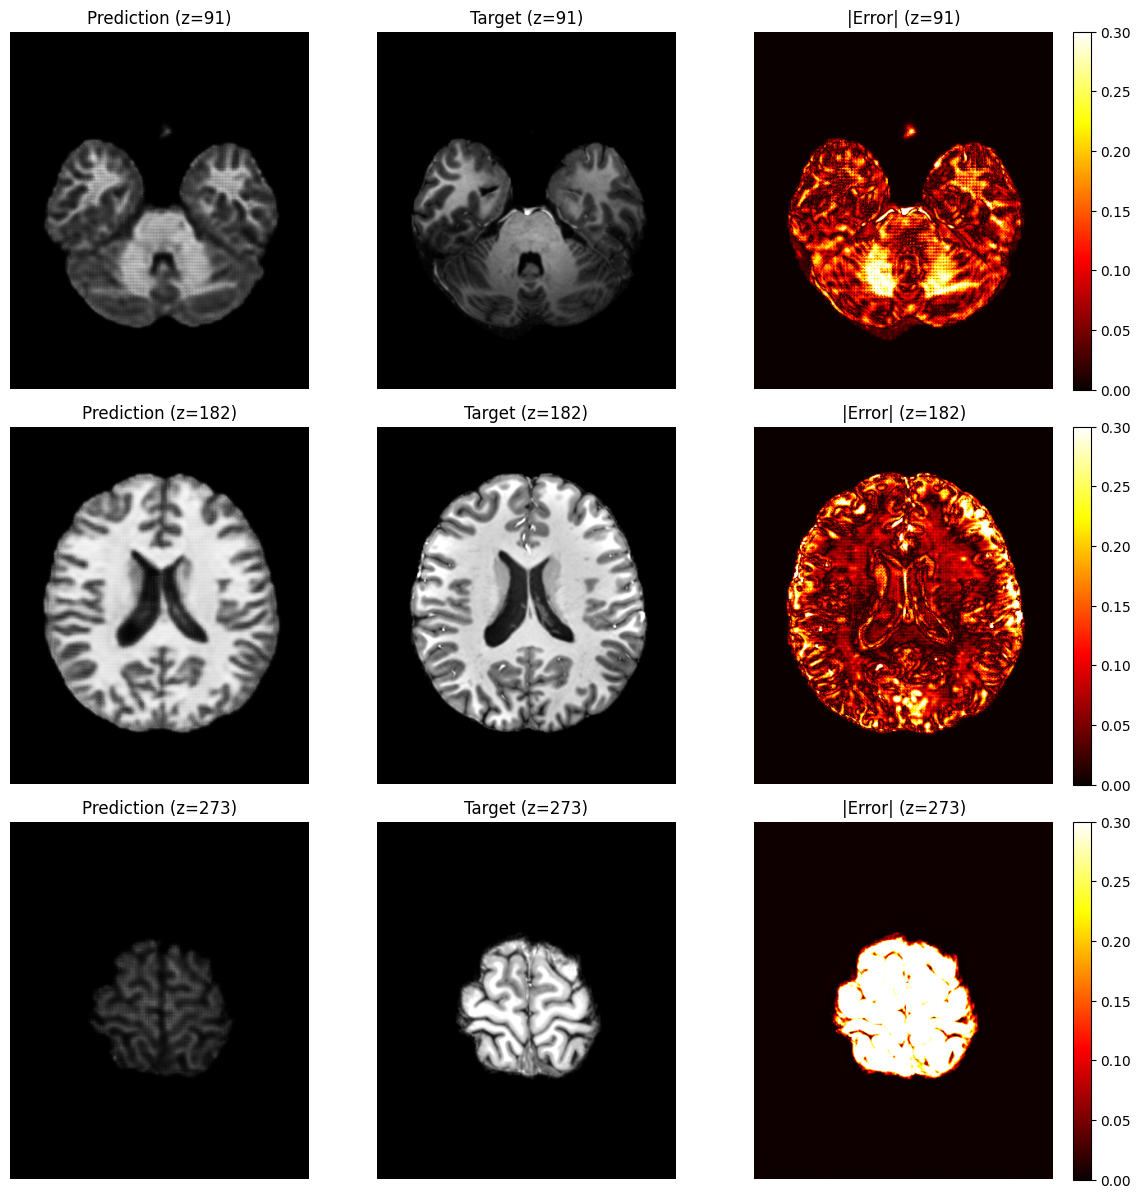

In [4]:
pred, _ = load_nifti(pred_path)
tgt, _  = load_nifti(tgt_path)

# Match the normalisation used by evaluate_pair
tgt_max = np.percentile(tgt, 99.5)
tgt_n = np.clip(tgt, 0, tgt_max) / max(tgt_max, 1e-8)
pred_n = np.clip(pred, 0, 1)  # already [0,1] from inference

Z = pred.shape[2]
slice_idx = [Z // 4, Z // 2, 3 * Z // 4]
fig, axes = plt.subplots(len(slice_idx), 3, figsize=(12, 4 * len(slice_idx)))
for row, z in enumerate(slice_idx):
    p, t = pred_n[:, :, z].T, tgt_n[:, :, z].T
    err = np.abs(p - t)
    axes[row, 0].imshow(p, cmap='gray', origin='lower', vmin=0, vmax=1)
    axes[row, 0].set_title(f'Prediction (z={z})')
    axes[row, 1].imshow(t, cmap='gray', origin='lower', vmin=0, vmax=1)
    axes[row, 1].set_title(f'Target (z={z})')
    im = axes[row, 2].imshow(err, cmap='hot', origin='lower', vmin=0, vmax=0.3)
    axes[row, 2].set_title(f'|Error| (z={z})')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)
    for ax in axes[row]: ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Batch evaluation

`evaluate_directory` matches predictions to targets by subject ID prefix, computes the metrics for each pair, prints a summary, and (optionally) writes a per-subject CSV.

In [5]:
csv_path = INFERENCE_DIR / 'eval_results.csv'

# Match predictions (*_pred.nii.gz) to ground truth by subject ID
metrics = ['nrmse', 'ssim', 'lpips']
all_results = []

for pred_path in sorted(INFERENCE_DIR.rglob('*_pred.nii.gz')):
    # Extract subject ID: P_T1W_7T_0007_pred.nii.gz -> 0007
    stem = pred_path.name.replace('_pred.nii.gz', '')
    subject = stem.split('_')[-1]
    tgt_path = target_dir / f'P_T1W_7T_{subject}.nii.gz'
    if not tgt_path.exists():
        print(f'  {subject}: target not found, skipping')
        continue

    result = evaluate_pair(pred_path, tgt_path, metrics=metrics)
    result['subject'] = subject
    all_results.append(result)
    vals = ' | '.join(f'{k}: {v:.4f}' for k, v in result.items() if k != 'subject')
    print(f'  {subject}: {vals}')

if all_results:
    import csv
    metric_cols = [k for k in all_results[0] if k != 'subject']
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['subject'] + metric_cols)
        w.writeheader()
        w.writerows(all_results)
    means = {k: np.mean([r[k] for r in all_results]) for k in metric_cols}
    print(f'\nMean:  ' + ' | '.join(f'{k}: {v:.4f}' for k, v in means.items()))
    print(f'Per-subject CSV saved.')
else:
    print('No matching pairs found.')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Loading model from: ...


  0007: nrmse: 0.3848 | ssim: 0.7388 | lpips: 0.1431

Mean:  nrmse: 0.3848 | ssim: 0.7388 | lpips: 0.1431
Per-subject CSV saved.


## 5. SynthSeg Segmentation

Run [SynthSeg 2.0](https://github.com/BBillot/SynthSeg) on the prediction and ground-truth volumes to produce brain segmentation maps. These are used to compute **Dice** overlap and **volume consistency** on 14 deep gray matter (DGM) structures.

In [6]:
# Run SynthSeg on prediction and ground truth
sys.path.insert(0, str(_tutorial / '..' / 'Evaluation'))
from segment import run_synthseg, _get_synthseg_dir

synthseg_dir = _get_synthseg_dir()

seg_dir = (_tutorial / 'tmp' / 'seg').resolve()
seg_dir.mkdir(parents=True, exist_ok=True)

# Segment prediction
pred_seg_path = seg_dir / pred_path.name.replace('.nii.gz', '_seg.nii.gz')
if not pred_seg_path.exists():
    print(f'Segmenting prediction: {pred_path.name}')
    run_synthseg(pred_path, pred_seg_path, synthseg_dir)
else:
    print(f'Prediction seg exists: {pred_seg_path.name}')

# Segment ground truth
tgt_seg_path = seg_dir / tgt_path.name.replace('.nii.gz', '_seg.nii.gz')
if not tgt_seg_path.exists():
    print(f'Segmenting target: {tgt_path.name}')
    run_synthseg(tgt_path, tgt_seg_path, synthseg_dir)
else:
    print(f'Target seg exists: {tgt_seg_path.name}')

print(f'\nSegmentations saved to: {seg_dir.relative_to(seg_dir.parent.parent)}')

Segmenting prediction: P_T1W_7T_0007_pred.nii.gz


2026-04-14 02:45:55.781853: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 02:45:55.781896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 02:45:55.783189: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 02:45:55.789361: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-04-14 02:45:56.592601: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2026-04-14 02:45:57.226615: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 02:45:57.229361: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 02:45:57.230887: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

L355
2026-04-14 02:45:57.235657: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 02:45:57.237405: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-14 02:45:57.238981: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#

...

predicting 1/1


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 1s 1s/step


2026-04-14 02:47:12.278615: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1089994752 exceeds 10% of free system memory.



segmentation  saved in:    ...

If you use this tool in a publication, please cite:
SynthSeg: domain randomisation for segmentation of brain MRI scans of any contrast and resolution
B. Billot, D.N. Greve, O. Puonti, A. Thielscher, K. Van Leemput, B. Fischl, A.V. Dalca, J.E. Iglesias

Segmentations saved to: tmp/seg


## 6. Visualize segmentation

Overlay SynthSeg labels on prediction and ground truth at three axial slices. SynthSeg 2.0 segments the brain into 32 structures (cortex, white matter, deep gray matter, ventricles, etc.). The 14 DGM structures used for Dice/Volume metrics are highlighted with thicker boundaries.

Seg shape: (182, 218, 182) (1mm isotropic)
Total structures: 32


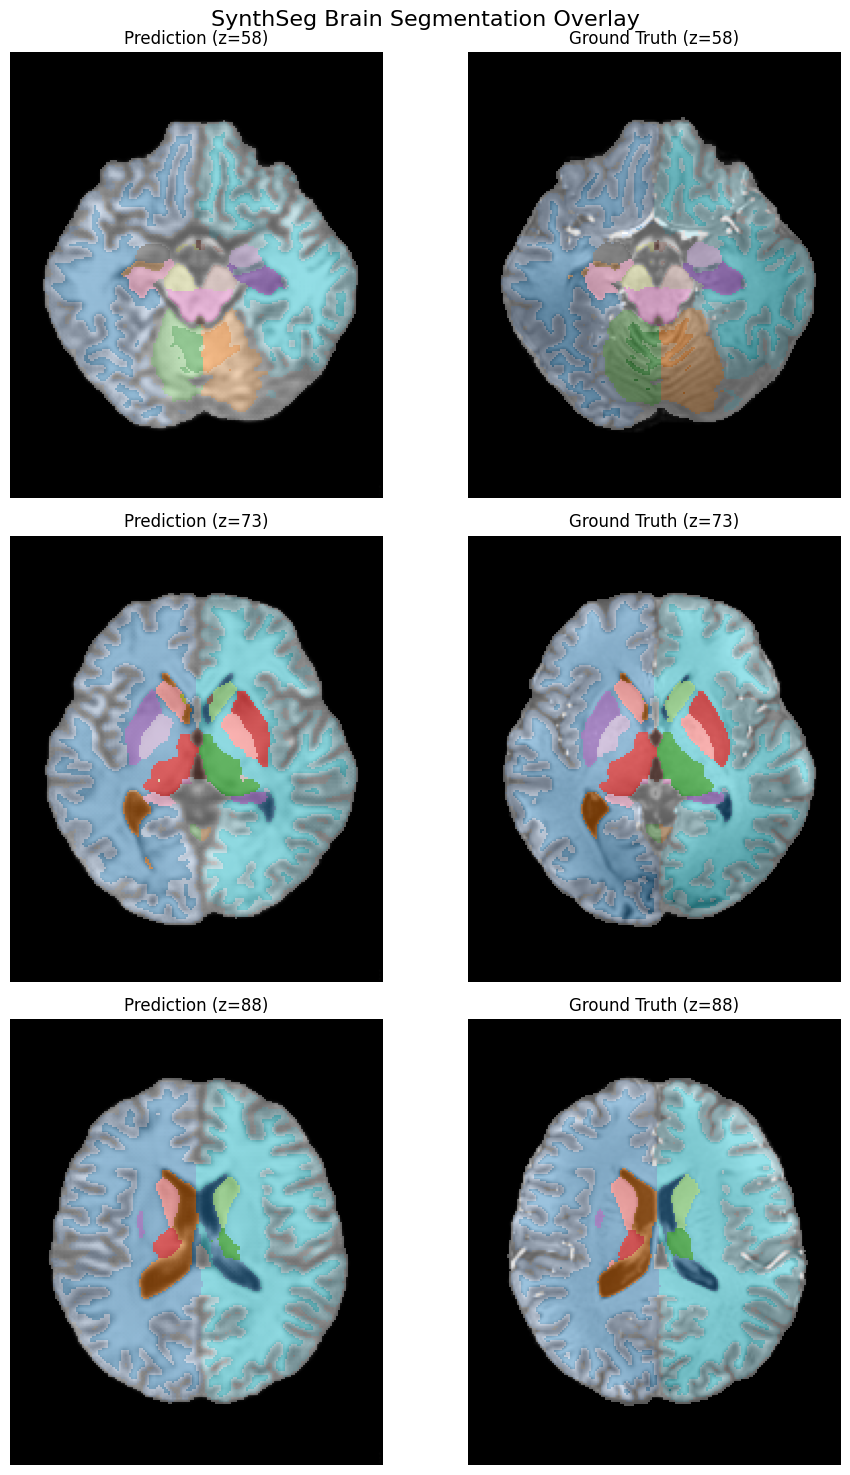

In [7]:
from evaluate import DGM_LABELS
from scipy.ndimage import zoom as ndi_zoom
import matplotlib.colors as mcolors

# Load segmentation maps (1mm isotropic, resampled by SynthSeg)
pred_seg_vol = nib.as_closest_canonical(nib.load(pred_seg_path)).get_fdata().astype(np.int32)
tgt_seg_vol  = nib.as_closest_canonical(nib.load(tgt_seg_path)).get_fdata().astype(np.int32)

all_labels = sorted(set(np.unique(pred_seg_vol)) | set(np.unique(tgt_seg_vol)))
all_labels = [l for l in all_labels if l != 0]
print(f'Seg shape: {pred_seg_vol.shape} (1mm isotropic)')
print(f'Total structures: {len(all_labels)}')

dgm_ids = set(DGM_LABELS.values())

# Downsample pred/tgt volumes to match seg resolution for overlay
pred_vol, _ = load_nifti(pred_path)
tgt_vol_raw, _ = load_nifti(tgt_path)
tgt_max = np.percentile(tgt_vol_raw, 99.5)
tgt_vol_n = np.clip(tgt_vol_raw, 0, tgt_max) / max(tgt_max, 1e-8)

scale = np.array(pred_seg_vol.shape) / np.array(pred_vol.shape)
pred_ds = ndi_zoom(pred_vol, scale, order=1)
tgt_ds  = ndi_zoom(tgt_vol_n, scale, order=1)

# Build a consistent colormap: map each label to a unique color
cmap_base = plt.colormaps.get_cmap('tab20').resampled(20)
label_colors = {}
for i, lbl in enumerate(all_labels):
    label_colors[lbl] = cmap_base(i % 20)

# Pick slices where DGM is visible (center of DGM range)
dgm_per_slice = [np.isin(pred_seg_vol[:, :, z], list(dgm_ids)).sum() for z in range(pred_seg_vol.shape[2])]
best_z = int(np.argmax(dgm_per_slice))
Z = pred_seg_vol.shape[2]
slice_idx = [best_z - 15, best_z, best_z + 15]
slice_idx = [max(0, min(z, Z - 1)) for z in slice_idx]

fig, axes = plt.subplots(len(slice_idx), 2, figsize=(10, 5 * len(slice_idx)))
for row, z in enumerate(slice_idx):
    for col, (vol, seg, title) in enumerate([
        (pred_ds, pred_seg_vol, 'Prediction'),
        (tgt_ds,  tgt_seg_vol,  'Ground Truth'),
    ]):
        ax = axes[row, col]
        ax.imshow(vol[:, :, z].T, cmap='gray', origin='lower', vmin=0, vmax=1)
        # Overlay all non-zero labels
        seg_slice = seg[:, :, z].T
        rgba = np.zeros((*seg_slice.shape, 4))
        for lbl in all_labels:
            mask = seg_slice == lbl
            if mask.any():
                c = label_colors[lbl]
                rgba[mask] = [c[0], c[1], c[2], 0.45]
                # DGM structures: slightly more opaque
                if lbl in dgm_ids:
                    rgba[mask] = [c[0], c[1], c[2], 0.7]
        ax.imshow(rgba, origin='lower', interpolation='nearest')
        ax.set_title(f'{title} (z={z})', fontsize=12)
        ax.axis('off')

fig.suptitle('SynthSeg Brain Segmentation Overlay', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Segmentation metrics — Dice & Volume Consistency

- **Dice coefficient**: spatial overlap per DGM structure. Range [0, 1], higher is better.
- **Volume consistency**: `1 - |V_pred - V_target| / V_target` per structure. Higher is better.

Both are computed over 14 bilateral DGM structures (7 pairs).

Structure               Dice    Volume
--------------------------------------
L_Thalamus            0.8857    0.8698
R_Thalamus            0.9073    0.9026
L_Caudate             0.8920    0.8786
R_Caudate             0.9038    0.8511
L_Putamen             0.8857    0.8673
R_Putamen             0.9104    0.9225
L_Pallidum            0.8560    0.7804
R_Pallidum            0.8703    0.7450
L_Hippocampus         0.8621    0.8895
R_Hippocampus         0.8577    0.8442
L_Amygdala            0.8421    0.7555
R_Amygdala            0.8199    0.7210
L_Accumbens           0.7987    0.8184
R_Accumbens           0.8410    0.9865
--------------------------------------
Mean                  0.8666    0.8452


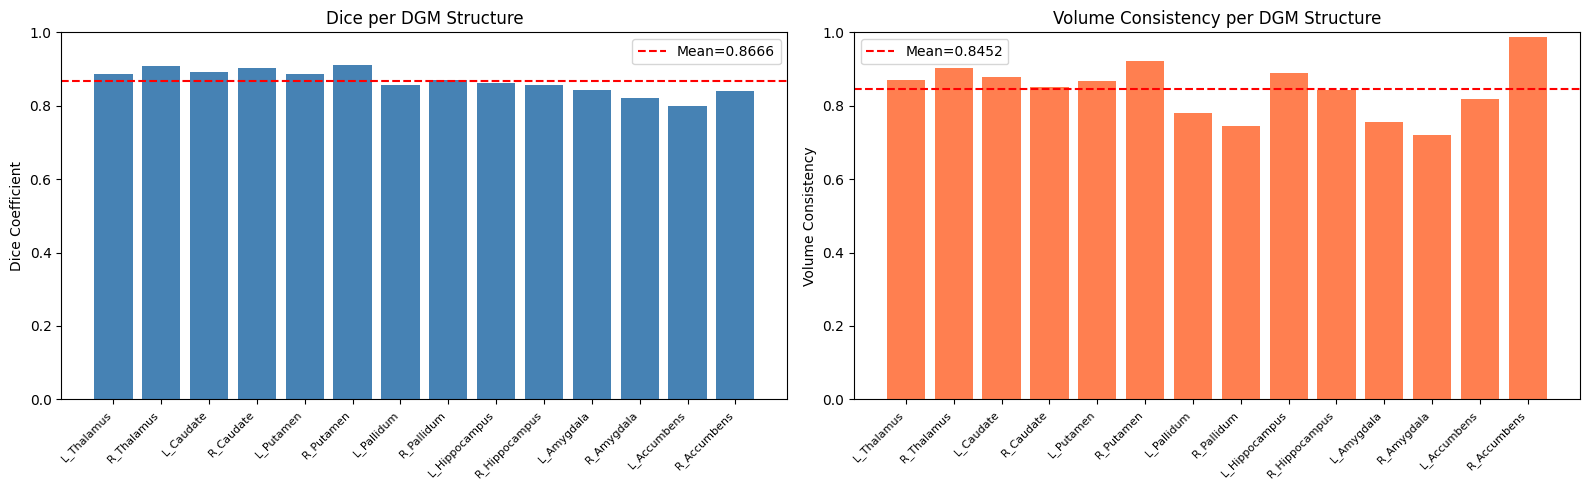

In [8]:
from evaluate import compute_dice, compute_volume_consistency, DGM_LABELS

# Compute per-structure Dice
dice_scores = compute_dice(pred_seg_vol, tgt_seg_vol, DGM_LABELS)

# Compute per-structure Volume Consistency
voxel_size = nib.load(tgt_path).header.get_zooms()[:3]
voxel_vol = float(np.prod(voxel_size))
vol_scores = compute_volume_consistency(pred_seg_vol, tgt_seg_vol, voxel_vol, DGM_LABELS)

# Display as a table
print(f'{"Structure":<20s}  {"Dice":>6s}  {"Volume":>8s}')
print('-' * 38)
for name in DGM_LABELS:
    print(f'{name:<20s}  {dice_scores[name]:6.4f}  {vol_scores[name]:8.4f}')
print('-' * 38)
mean_dice = np.mean(list(dice_scores.values()))
mean_vol  = np.mean(list(vol_scores.values()))
print(f'{"Mean":<20s}  {mean_dice:6.4f}  {mean_vol:8.4f}')

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

names = list(DGM_LABELS.keys())
x = np.arange(len(names))

ax1.bar(x, [dice_scores[n] for n in names], color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Dice Coefficient')
ax1.set_ylim(0, 1)
ax1.axhline(mean_dice, color='red', linestyle='--', label=f'Mean={mean_dice:.4f}')
ax1.legend()
ax1.set_title('Dice per DGM Structure')

ax2.bar(x, [vol_scores[n] for n in names], color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Volume Consistency')
ax2.set_ylim(0, 1)
ax2.axhline(mean_vol, color='red', linestyle='--', label=f'Mean={mean_vol:.4f}')
ax2.legend()
ax2.set_title('Volume Consistency per DGM Structure')

plt.tight_layout()
plt.show()

## Next Steps

Full evaluation from the CLI (matches the batch loop above):

```bash
python Evaluation/evaluate.py \
    --pred_dir   $INFERENCE_DIR \
    --target_dir $DATA_DIR/Validating_prospective/T1W/7T \
    --output_csv $INFERENCE_DIR/../eval_results.csv \
    --metrics nrmse ssim lpips
```

Add `--pred_seg_dir` / `--target_seg_dir` and `--metrics ... dice volume` once SynthSeg has run.